# VMPD Worked Example: Pipeline Attestation and Digital Rights

**A combined analysis of GDPR, the EU AI Act, and PIPEDA**

**Vulnerability Management for Policy Design (VMPD) v1.0**

This notebook is a worked example of VMPD applied to three rights-and-data governance regimes: the General Data Protection Regulation (GDPR), the EU AI Act (Regulation 2024/1689), and the Personal Information Protection and Electronic Documents Act (PIPEDA). It accompanies the analysis published in Bhardwaj, B. (2026), *Security-by-design: A Case for Digital Rights Enforcement Through Data Pipeline Attestations*, and extends that analysis to PIPEDA.

The purpose is to demonstrate the VMPD methodology applied to substantive regimes, with documented analyst rationale for each scoring judgment.

**Note:** The scores represent the analyst's judgment as of v1.0 and are open to contestation.

## Setup

In [18]:
import sys
sys.path.append('../src')
from vmpd_engine import *

## Regime context

In [19]:
analysis = new_analysis(
    regime_name='GDPR + EU AI Act + PIPEDA (Combined Rights-and-Data Governance Analysis)',
    analyst='Bhavyatta Bhardwaj',
    operational_context='Three rights-and-data governance regimes operating across overlapping jurisdictions: GDPR (EU, processing of personal data), the EU AI Act (EU, AI systems placed on the EU market or whose outputs are used in the EU), and PIPEDA (Canada, federal private-sector commercial activity). All three regimes operate in environments where generative and agentic AI systems condition data upstream of regulated processing endpoints, where capability-based risks emerge prior to declared use, and where affected populations bear substantial costs of triggering enforcement.',
    accountability_frame='GDPR holds data controllers and processors accountable for lawful, fair, and transparent processing of personal data. The EU AI Act holds providers and deployers accountable for risk-tier-appropriate obligations. PIPEDA holds private-sector organisations accountable for collection, use, and disclosure of personal information based on meaningful consent. Across all three, accountability is asserted for outcomes but the upstream conditions producing those outcomes are not systematically governed. Climate, energy, and environmental authorities bear accountability for downstream environmental outcomes of AI infrastructure but are not structurally required in the coordination architecture of any of the three regimes.'
)

print(f'Analysis created: {analysis.regime_name}')
print(f'Analyst: {analysis.analyst}')
print(f'Date: {analysis.date}')

Analysis created: GDPR + EU AI Act + PIPEDA (Combined Rights-and-Data Governance Analysis)
Analyst: Bhavyatta Bhardwaj
Date: 2026-05-12


---

## Examination 1: Legibility Analysis

What conditions does each regime depend on but cannot see?

Two vulnerabilities are surfaced here, one in GDPR and one in the EU AI Act.

In [20]:
v1 = analysis.add_vulnerability(
    name='GDPR governs processing endpoints, leaving the upstream layer as the exploitable surface',
    location='GDPR Article 2 (material scope) and Article 4 (definitions of "processing" and "personal data"). The exploit surface is the scope as anything operating upstream of what the regime defines as "processing" of "personal data" falls outside the regime\'s reach by definition.',
    description='GDPR\'s structural reach is defined by what counts as processing of personal data. Any actor operating upstream of that definition (sourcing, transforming, weighting, conditioning data before it becomes "personal data being processed") operates in a zone the regime cannot see, cannot audit, and cannot enforce against. The exploit is to extract value from data subjects\' information through upstream operations that never trigger the regime\'s protections, because the regime\'s scope ends where the exploitable surface begins.',
    rationale='The endpoint-only scope of GDPR is by design that the regime drafted in a context where the processing layer was the operationally consequential one. That assumption no longer holds because upstream conditioning is where representational choices, exclusion patterns, and downstream behaviour get determined. Any actor doing this work upstream of the GDPR scope can do it without attestation, audit, subject rights attaching, or enforcement risk. This is a structural vulnerability in the scope that defines what\'s exploitable.',
    beneficiaries='Any actor performing data sourcing, transformation, weighting, or conditioning upstream of the GDPR-defined processing endpoint. AI providers training on conditioned data are a current example, but the same exploit is available to data brokers, dataset assemblers, training data marketplaces, and any actor that touches data before it becomes "personal data being processed."',
    impacted_populations='Data subjects whose information is conditioned in ways they cannot see, contest, or seek redress for, because the regime that claims to protect them does not reach the layer where the exploitation occurs.',
    upstream_visibility=4,
    process_specification=3,
    inherited_trust=4,
    verification_authority=3,
    accountability_inclusion_ratio=2,
    domain_authority_coverage=2,
    affected_party_standing=2,
    coordination_specificity=2,
    threshold_definition=2,
    obligation_bindingness=1,
    deferred_process_density=2,
    exception_architecture=2,
    pattern_recognition_assignment=3,
    detection_capability_requirement=3,
    trigger_specificity=2,
    response_architecture_coherence=2,
    mechanism_existence=1,
    mechanism_accessibility=3,
    cost_distribution=3,
    pre_enforcement_recourse=3,
)

print(f'V1: {v1.name}')
print(f'   Base score: {v1.base_score()} ({v1.severity_label()})')

V1: GDPR governs processing endpoints, leaving the upstream layer as the exploitable surface
   Base score: 6.13 (High)


In [21]:
v2 = analysis.add_vulnerability(
    name='EU AI Act creates the appearance of upstream visibility while leaving conditioning operations as the exploitable surface',
    location='EU AI Act Article 53(1)(d) (training data summary disclosure obligation for general-purpose AI providers) and Annex XI (technical documentation requirements). The exploitable surface is the gap between what the regime requires to be disclosed (which datasets were used) and what it does not require to be attested (how those datasets were conditioned during transformation, weighting, filtering, structuring operations).',
    description='The Act requires providers of general-purpose AI models to disclose information about training data. Disclosure of dataset identity satisfies the obligation as written. Conditioning operations applied to those datasets are not subject to attestation. The exploit is to satisfy the disclosure requirement while operating freely in the conditioning layer, where the substantive choices about representation, exclusion, weighting, and filtering get made.',
    rationale='The Act\'s disclosure provision moves directionally toward upstream visibility, which is meaningful because it\'s the first such move in major AI regulation. But disclosure is not attestation. An attested record of dataset origin is not proof of conditioning integrity. The regime creates the appearance of upstream governance while leaving the operationally consequential layer ungoverned. The exploit is structural: anyone meeting the disclosure obligation as written can do whatever they want in conditioning, and there is no authority required to verify the conditioning operations themselves.',
    beneficiaries='Providers of general-purpose AI models who satisfy the disclosure obligation while making conditioning choices that determine system behaviour. Downstream deployers and integrators who rely on conditioned models without ability to verify the conditioning choices.',
    impacted_populations='Affected parties whose representational characteristics are encoded, weighted, excluded, or distorted through conditioning operations they cannot see, contest, or evaluate. Downstream actors who inherit the consequences of conditioning choices made upstream of any audit point.',
    upstream_visibility=2,
    process_specification=3,
    inherited_trust=3,
    verification_authority=3,
    accountability_inclusion_ratio=2,
    domain_authority_coverage=2,
    affected_party_standing=3,
    coordination_specificity=2,
    threshold_definition=2,
    obligation_bindingness=2,
    deferred_process_density=2,
    exception_architecture=2,
    pattern_recognition_assignment=2,
    detection_capability_requirement=3,
    trigger_specificity=2,
    response_architecture_coherence=2,
    mechanism_existence=2,
    mechanism_accessibility=3,
    cost_distribution=3,
    pre_enforcement_recourse=3,
)

print(f'V2: {v2.name}')
print(f'   Base score: {v2.base_score()} ({v2.severity_label()})')

V2: EU AI Act creates the appearance of upstream visibility while leaving conditioning operations as the exploitable surface
   Base score: 6.0 (High)


In [22]:
v3 = analysis.add_vulnerability(
    name='PIPEDA collection-use-disclosure scope leaves the conditioning of personal information as the exploitable surface',
    location='PIPEDA Schedule 1 Principle 4 (Limiting Collection), Principle 5 (Limiting Use, Disclosure, and Retention), and s.2(1) (definition of "personal information"). The exploitable surface is the gap between PIPEDA\'s defined scope (acts of collection, use, and disclosure of identifiable personal information) and the conditioning operations applied to that information once collected. These are operations that determine what the information becomes before it reaches any "use" the regime can identify.',
    description='PIPEDA\'s structure defines what\'s governable as discrete acts: collecting, using, and disclosing personal information. The conditioning operations applied between collection and use (transformation, aggregation, weighting, structuring, embedding into training material) are not separately governed. Once personal information is collected for an identified purpose, the regime treats subsequent conditioning as part of the "use" without requiring attestation of how the conditioning was performed. The exploit is to collect under one stated purpose, then condition the collected information in ways that materially change what it becomes, while remaining formally compliant with collection and use limitations.',
    rationale='PIPEDA was drafted around a model of personal information as discrete, identifiable records moved between defined points (collected here, used there, disclosed elsewhere). Conditioning operations that transform records into training material, embeddings, derived datasets, or aggregated profiles do not map cleanly onto this model. The regime cannot see what\'s happening in the conditioning layer because its scope is defined by acts on records rather than transformations of records. The vulnerability is structural: the scope itself defines what\'s exploitable, and the conditioning layer falls outside it by definition.',
    beneficiaries='Any organisation collecting personal information under PIPEDA-compliant purposes and then conditioning that information for AI training, analytics, derived dataset construction, or profile aggregation. Data brokers and analytics providers who condition collected data without triggering fresh collection or disclosure obligations.',
    impacted_populations='Individuals whose personal information is conditioned in ways they cannot see, contest, or seek redress for through PIPEDA\'s existing complaint mechanisms, because the conditioning falls outside the regime\'s scope of regulated acts.',
    upstream_visibility=4,
    process_specification=3,
    inherited_trust=4,
    verification_authority=3,
    accountability_inclusion_ratio=2,
    domain_authority_coverage=2,
    affected_party_standing=2,
    coordination_specificity=2,
    threshold_definition=2,
    obligation_bindingness=1,
    deferred_process_density=2,
    exception_architecture=2,
    pattern_recognition_assignment=3,
    detection_capability_requirement=3,
    trigger_specificity=2,
    response_architecture_coherence=2,
    mechanism_existence=2,
    mechanism_accessibility=4,
    cost_distribution=4,
    pre_enforcement_recourse=3,
)

print(f'V3: {v3.name}')
print(f'   Base score: {v3.base_score()} ({v3.severity_label()})')

V3: PIPEDA collection-use-disclosure scope leaves the conditioning of personal information as the exploitable surface
   Base score: 6.5 (High)


---

## Examination 2: Architecture Analysis

Which actors will be held accountable for outcomes the regimes address but are absent from their coordination architectures?

One cross-regime vulnerability is surfaced here.

In [23]:
v4 = analysis.add_vulnerability(
    name='Climate, energy, and environmental authorities have no statutory standing in any of the three regimes\' coordination architectures, leaving AI infrastructure decisions as the exploitable surface',
    location='Cross-regime structural absence: EU AI Act Articles 56-69 (governance architecture: AI Office, European AI Board, national competent authorities) - environmental authorities not required. GDPR Articles 51-59 (supervisory authorities, EDPB, cooperation mechanisms) - environmental authorities not required. PIPEDA Part 2 (administration; Office of the Privacy Commissioner) - environmental authorities not required. The exploitable surface is the entire AI infrastructure decision-making layer (compute capacity, data centres, training operations, deployment systems) governed through these three regimes without environmental authority involvement.',
    description='None of the three regimes structurally require climate, energy, or environmental authorities in their coordination architecture. AI infrastructure decisions get made through these architectures with substantial environmental consequences (grid load, water use, emissions, resource extraction) that those authorities will be held accountable for downstream. The exploit is to make AI infrastructure decisions through the AI/data governance architecture without environmental authority involvement, because those authorities have no statutory standing to insert themselves into the decision-making.',
    rationale='Climate is everyone\'s responsibility, especially the responsibility of those contributing most to it. Climate, energy, and environmental departments have spent years sounding the alarm on infrastructure-driven emissions and resource use. Yet none of the three regimes give them a defined role in assessing AI infrastructure compatibility with environmental obligations. The exclusion is consistent across regimes and produces accountability without authority: the bodies accountable for environmental outcomes have no governance standing over the infrastructure producing those outcomes. The vulnerability is structural and cross-regime.',
    beneficiaries='AI providers and deployers operating infrastructure without environmental authority oversight. Jurisdictions competing for AI infrastructure investment without requiring environmental authority sign-off. Regimes whose own scope expansion is enabled by the absence of cross-domain coordination requirements.',
    impacted_populations='Climate, energy, and environmental authorities held accountable for outcomes they have no role in shaping. Populations bearing environmental costs of AI infrastructure (grid load, water use, emissions). Future generations inheriting infrastructure decisions made through governance architectures that excluded environmental authority by design.',
    upstream_visibility=3,
    process_specification=2,
    inherited_trust=2,
    verification_authority=3,
    accountability_inclusion_ratio=4,
    domain_authority_coverage=4,
    affected_party_standing=3,
    coordination_specificity=4,
    threshold_definition=3,
    obligation_bindingness=3,
    deferred_process_density=2,
    exception_architecture=2,
    pattern_recognition_assignment=3,
    detection_capability_requirement=3,
    trigger_specificity=3,
    response_architecture_coherence=3,
    mechanism_existence=2,
    mechanism_accessibility=3,
    cost_distribution=3,
    pre_enforcement_recourse=3,
)

print(f'V4: {v4.name}')
print(f'   Base score: {v4.base_score()} ({v4.severity_label()})')

V4: Climate, energy, and environmental authorities have no statutory standing in any of the three regimes' coordination architectures, leaving AI infrastructure decisions as the exploitable surface
   Base score: 7.25 (High)


---

## Examination 3: Specificity Analysis

Where does the regime use language that signals commitment without enforceable specificity? Where do thresholds, triggers, or required actions depend on judgments that no authority is required to make?

One vulnerability is surfaced here.

In [24]:
v5 = analysis.add_vulnerability(
    name='EU AI Act risk classification triggered by deployer-declared use rather than system capability creates the exploitable surface',
    location='EU AI Act Article 6 (classification rules for high-risk AI systems) and Annex III (list of high-risk use cases). The exploitable surface is the classification trigger when the regime treats a system as high-risk only when a deployer\'s declared use falls within Annex III categories. Capability that exceeds or differs from the declared use is not the trigger. This means a system can possess high-risk capability and operate in the deployment environment without entering the high-risk regulatory tier, as long as the deployer\'s declared use stays outside Annex III.',
    description='The Act classifies AI systems based on what deployers say they\'re being used for, not what the systems can actually do. A general-purpose system with capability to perform high-risk functions becomes a governed high-risk system only at the moment a deployer declares a high-risk use. The exploit is to deploy systems with high-risk capability under a lower-risk declared use, satisfying the regime\'s classification logic while operating in environments where the high-risk capability is present and exploitable. There is no authority required to verify that the declared use matches the system\'s actual capability surface.',
    rationale='The use-case classification framework is well-designed for systems with bounded, declared functionality where capability and use are tightly coupled. It is structurally inadequate for general-purpose AI systems where capability exceeds any single declared use, and for any deployment context where the deployer\'s declaration may not match operational reality. The trigger depends on a deployer judgment that no authority is required to verify against capability assessment. The exploit is structural: the regime\'s high-risk obligations attach to a declaration the regime does not verify.',
    beneficiaries='Providers and deployers of general-purpose AI systems who can frame deployments under non-Annex-III uses while the underlying systems retain high-risk capability. Deployers preferring lower-tier obligations who can structure declared use to remain below the classification threshold. Market actors competing against operators who classify their high-risk capabilities honestly.',
    impacted_populations='Anyone affected by AI systems whose capability exceeds the deployer\'s declared use without triggering the regime\'s high-risk obligations. Operators who declare honestly and bear higher compliance costs than competitors who structure declarations strategically. Downstream actors who interact with systems classified below their actual capability tier.',
    upstream_visibility=3,
    process_specification=3,
    inherited_trust=3,
    verification_authority=3,
    accountability_inclusion_ratio=2,
    domain_authority_coverage=2,
    affected_party_standing=3,
    coordination_specificity=2,
    threshold_definition=3,
    obligation_bindingness=2,
    deferred_process_density=3,
    exception_architecture=3,
    pattern_recognition_assignment=3,
    detection_capability_requirement=3,
    trigger_specificity=3,
    response_architecture_coherence=2,
    mechanism_existence=2,
    mechanism_accessibility=3,
    cost_distribution=3,
    pre_enforcement_recourse=3,
)

print(f'V5: {v5.name}')
print(f'   Base score: {v5.base_score()} ({v5.severity_label()})')

V5: EU AI Act risk classification triggered by deployer-declared use rather than system capability creates the exploitable surface
   Base score: 6.75 (High)


---

## Examination 4: Pattern Responsibility Analysis

Where does the regime assume pattern recognition that should trigger response, without assigning the monitoring function to a specific authority?

One vulnerability is surfaced here.

In [25]:
v6 = analysis.add_vulnerability(
    name='EU AI Act response architecture is reactive, leaving the pre-incident period as the exploitable surface',
    location='EU AI Act Articles 73-79 (post-market monitoring, serious incident reporting, market surveillance), Articles 51-55 (systemic risk for general-purpose AI models), and Articles 64-66 (AI Office, European AI Board, advisory forum). The exploitable surface is the time during which precursor patterns of harm develop and consolidate without triggering any monitoring function the regime has actually assigned. That\'s the entire pre-incident period. The Act establishes mechanisms to respond to incidents that have already occurred and obligates providers to report them, but no authority is required to perform proactive pattern recognition across deployed systems before incidents consolidate.',
    description='The Act\'s response architecture activates after harm. Post-market monitoring is the provider\'s obligation. Incident reporting is triggered by serious incidents that have already occurred. Systemic risk classification depends on compute thresholds being met, not on emergent patterns being recognised. The exploit is to operate AI systems through the period in which precursor patterns develop and consolidate into incidents, because no authority is required to look for those patterns before they trigger the regime\'s response mechanisms. By the time an incident is reported, the harm has already occurred, and any patterns that would have predicted it remain unrecognised because the function of recognising them was never assigned to anyone.',
    rationale='Pattern recognition prior to incident consolidation requires a named authority with the mandate, capability, and access to cross-system data necessary to perform proactive monitoring. The AI Office has coordination responsibility but not an operational pattern recognition mandate. National competent authorities have jurisdiction-specific responsibility but not cross-jurisdiction pattern recognition. The Board and advisory forum have governance and consultation roles but not surveillance functions. The vulnerability is structural: the regime assumes pattern recognition is happening somewhere without assigning the function, and the exploitable surface is the entire pre-incident period during which patterns develop unobserved.',
    beneficiaries='Providers and deployers of AI systems that exhibit precursor patterns of harm during the pre-incident period, because no authority is required to identify those patterns before they trigger reportable incidents. Operators of systems whose accumulated effects across the deployed base are visible only through cross-system pattern recognition that the regime does not require anyone to perform.',
    impacted_populations='Affected populations exposed to systemic AI harms that escalate from precursor patterns to incidents to crises without coordinated regulatory response, because the patterns were not being looked for before incidents consolidated. Future affected parties whose harm is encoded in patterns that are present in current data but unrecognised because no authority is assigned to recognise them.',
    upstream_visibility=3,
    process_specification=3,
    inherited_trust=2,
    verification_authority=3,
    accountability_inclusion_ratio=3,
    domain_authority_coverage=3,
    affected_party_standing=3,
    coordination_specificity=3,
    threshold_definition=3,
    obligation_bindingness=2,
    deferred_process_density=3,
    exception_architecture=2,
    pattern_recognition_assignment=4,
    detection_capability_requirement=4,
    trigger_specificity=3,
    response_architecture_coherence=2,
    mechanism_existence=2,
    mechanism_accessibility=3,
    cost_distribution=3,
    pre_enforcement_recourse=4,
)

print(f'V6: {v6.name}')
print(f'   Base score: {v6.base_score()} ({v6.severity_label()})')

V6: EU AI Act response architecture is reactive, leaving the pre-incident period as the exploitable surface
   Base score: 7.25 (High)


---

## Outputs

In [26]:
analysis.summary_table()

,name,location,description,rationale,beneficiaries,impacted_populations,base_score,severity,legibility_score,architecture_score,specificity_score,pattern_responsibility_score,recourse_score
0,"GDPR governs processing endpoints, leaving the...",GDPR Article 2 (material scope) and Article 4 ...,GDPR's structural reach is defined by what cou...,The endpoint-only scope of GDPR is by design t...,"Any actor performing data sourcing, transforma...",Data subjects whose information is conditioned...,6.13,High,8.75,5.00,4.38,6.25,6.25
1,EU AI Act creates the appearance of upstream v...,EU AI Act Article 53(1)(d) (training data summ...,The Act requires providers of general-purpose ...,The Act's disclosure provision moves direction...,Providers of general-purpose AI models who sat...,Affected parties whose representational charac...,6.00,High,6.88,5.62,5.00,5.62,6.88
2,PIPEDA collection-use-disclosure scope leaves ...,PIPEDA Schedule 1 Principle 4 (Limiting Collec...,PIPEDA's structure defines what's governable a...,PIPEDA was drafted around a model of personal ...,Any organisation collecting personal informati...,Individuals whose personal information is cond...,6.50,High,8.75,5.00,4.38,6.25,8.12
3,"Climate, energy, and environmental authorities...",Cross-regime structural absence: EU AI Act Art...,None of the three regimes structurally require...,"Climate is everyone's responsibility, especial...",AI providers and deployers operating infrastru...,"Climate, energy, and environmental authorities...",7.25,High,6.25,9.38,6.25,7.50,6.88
4,EU AI Act risk classification triggered by dep...,EU AI Act Article 6 (classification rules for ...,The Act classifies AI systems based on what de...,The use-case classification framework is well-...,Providers and deployers of general-purpose AI ...,Anyone affected by AI systems whose capability...,6.75,High,7.50,5.62,6.88,6.88,6.88
5,"EU AI Act response architecture is reactive, l...",EU AI Act Articles 73-79 (post-market monitori...,The Act's response architecture activates afte...,Pattern recognition prior to incident consolid...,Providers and deployers of AI systems that exh...,Affected populations exposed to systemic AI ha...,7.25,High,6.88,7.50,6.25,8.12,7.50


In [ ]:
comparison_chart(analysis)

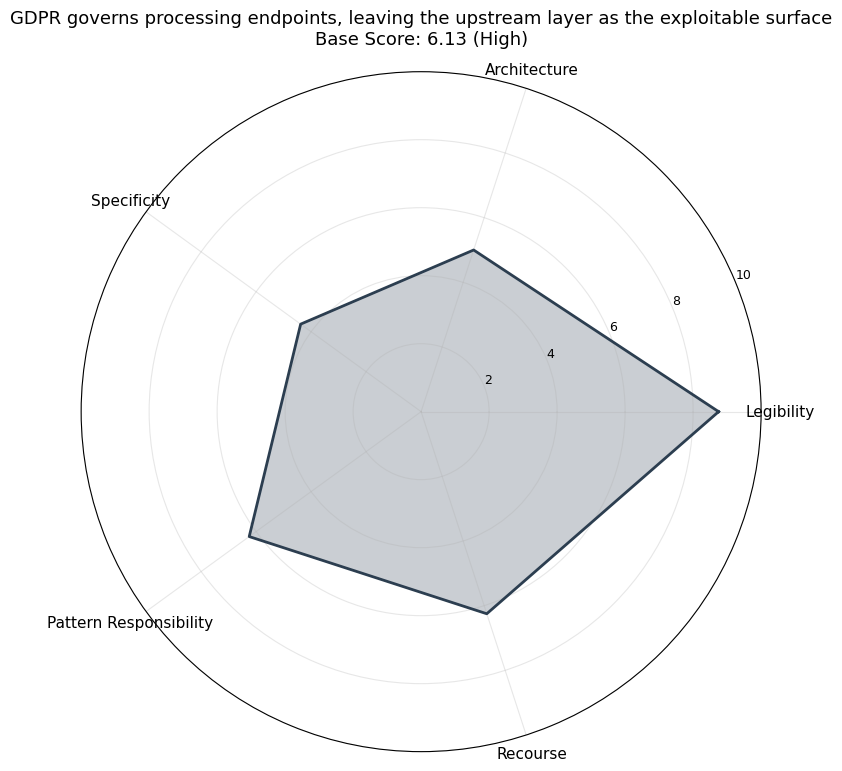

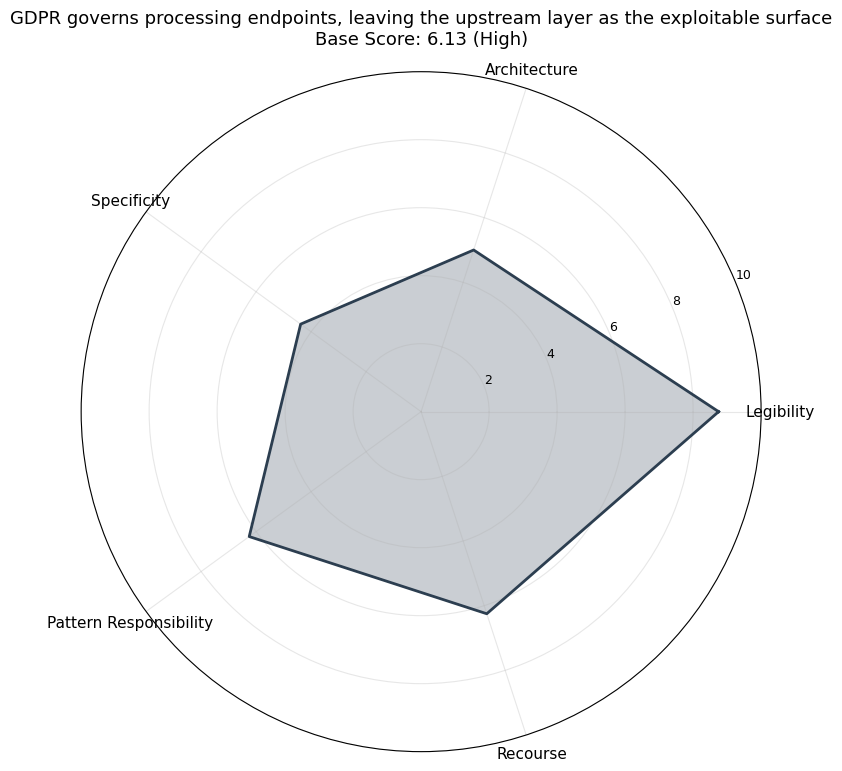

In [28]:
radar_chart(v1)

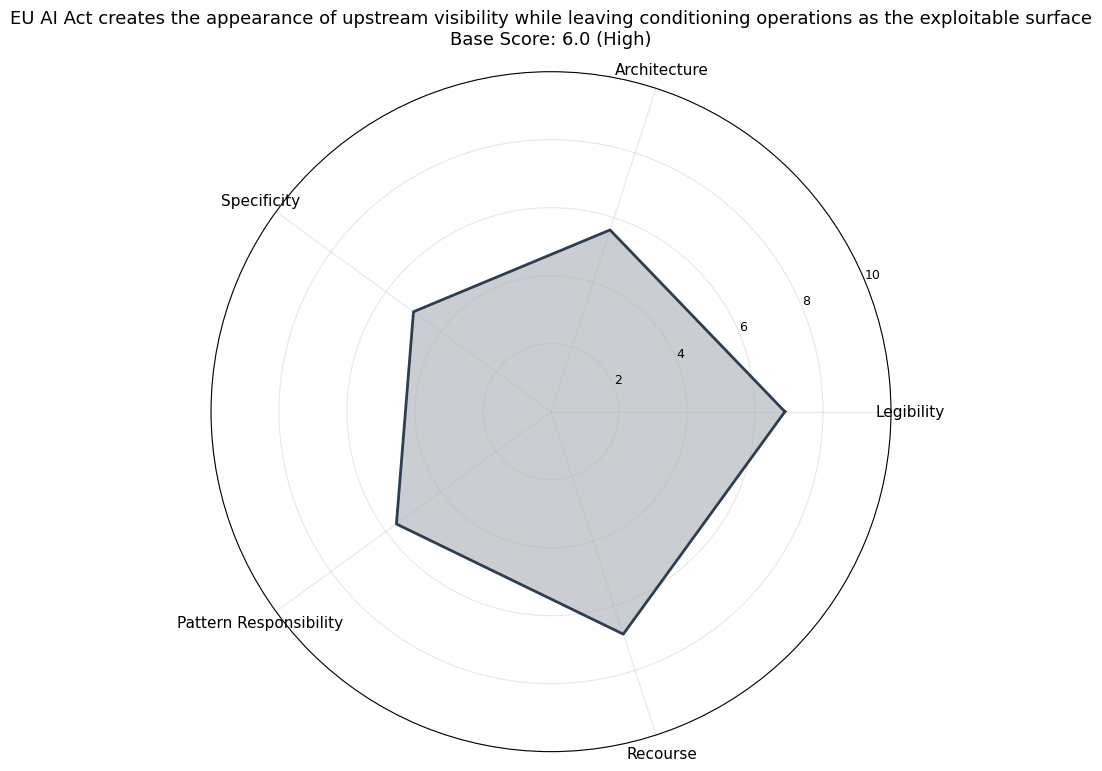

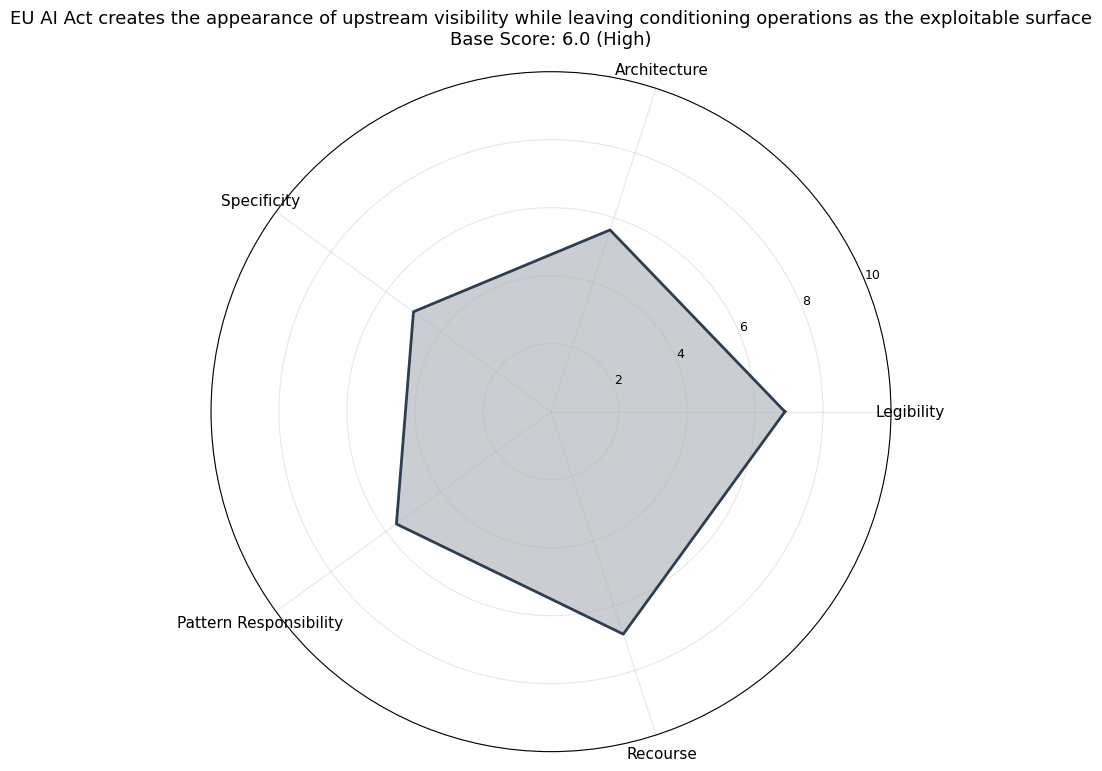

In [29]:
radar_chart(v2)

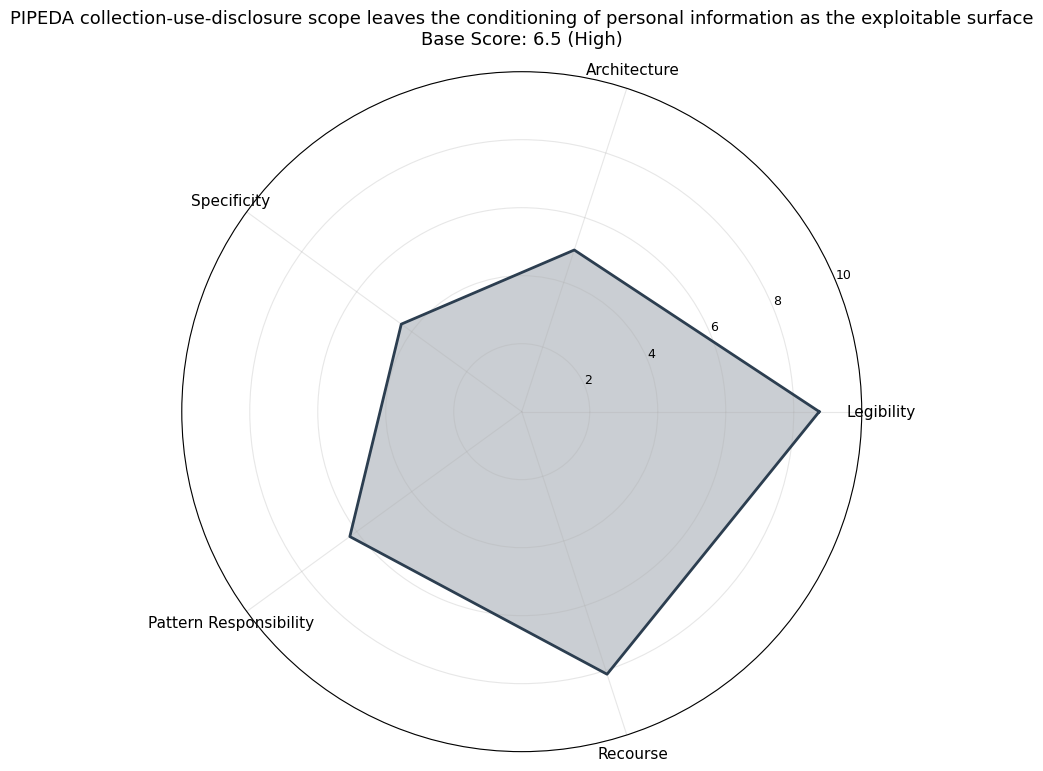

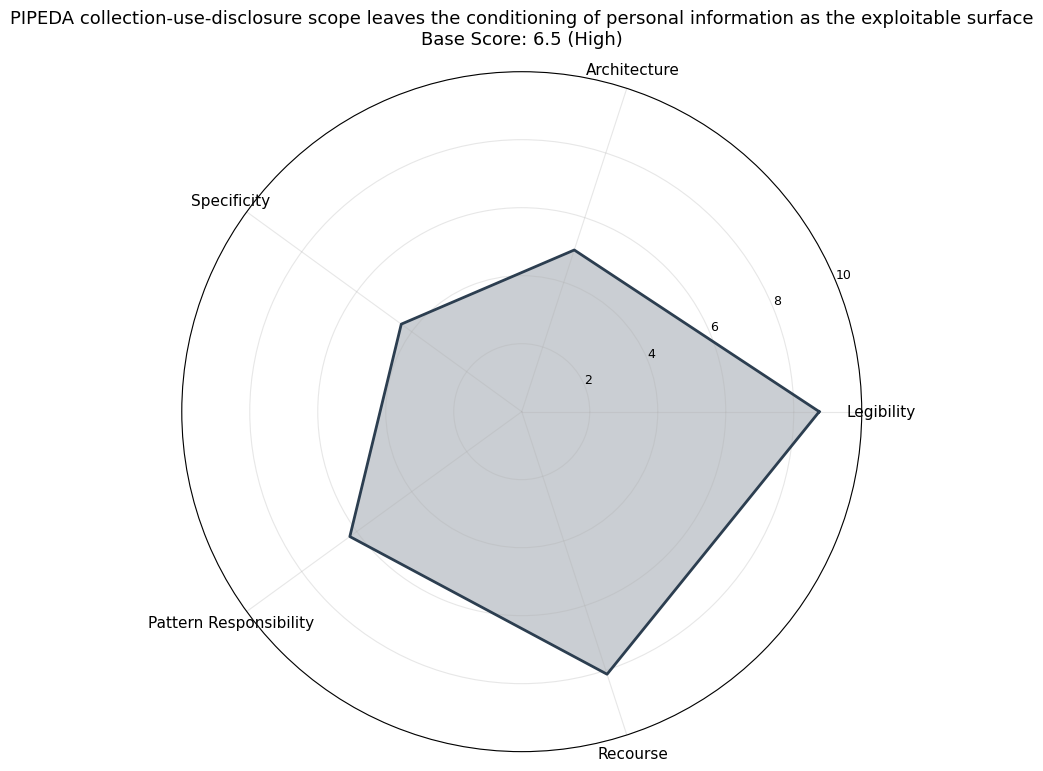

In [30]:
radar_chart(v3)

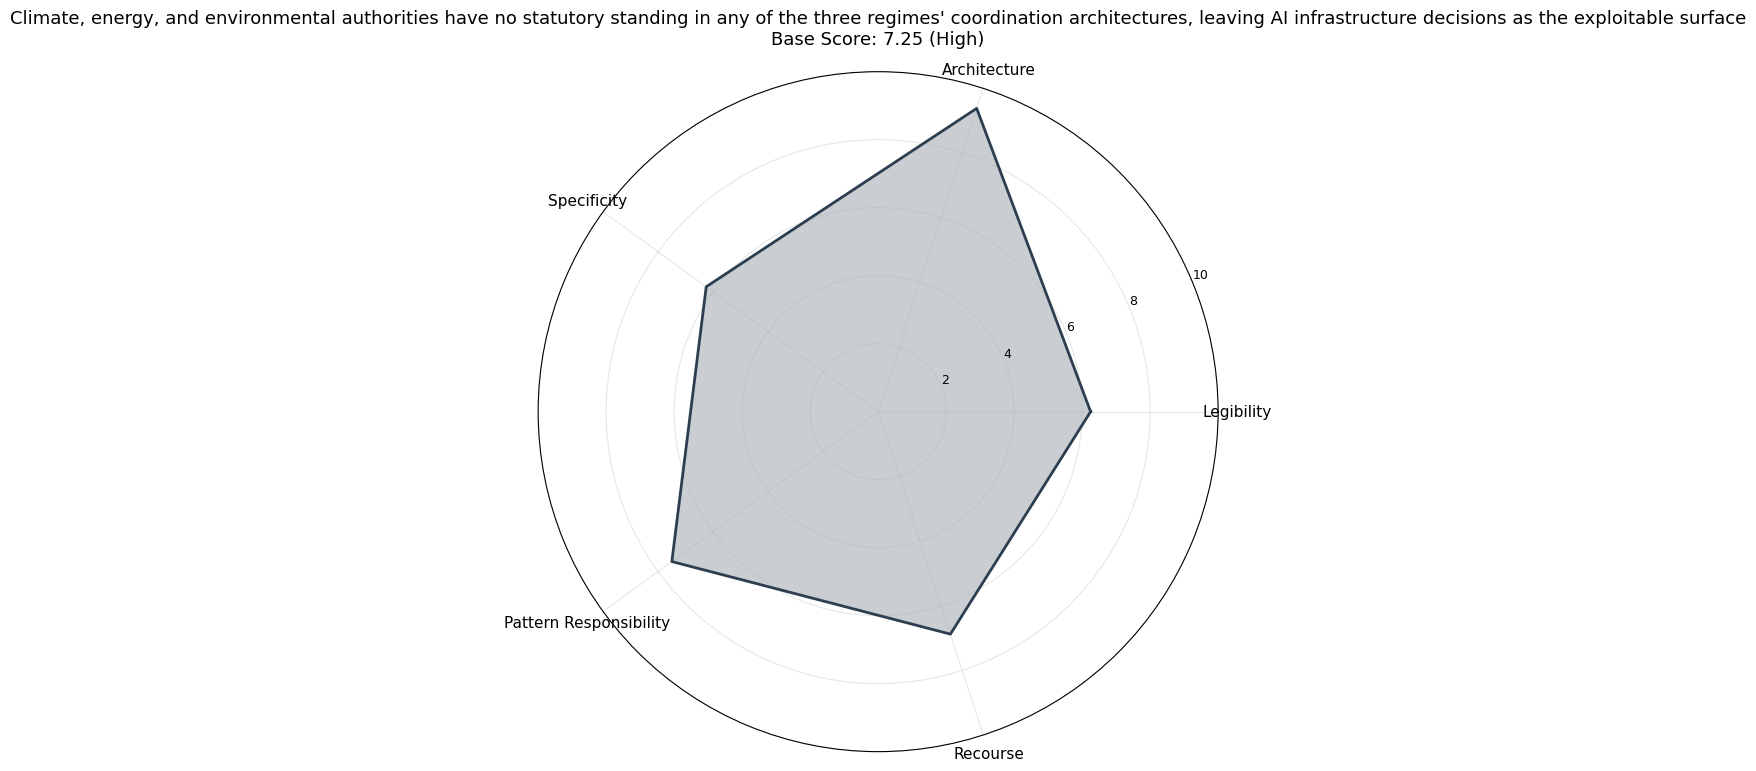

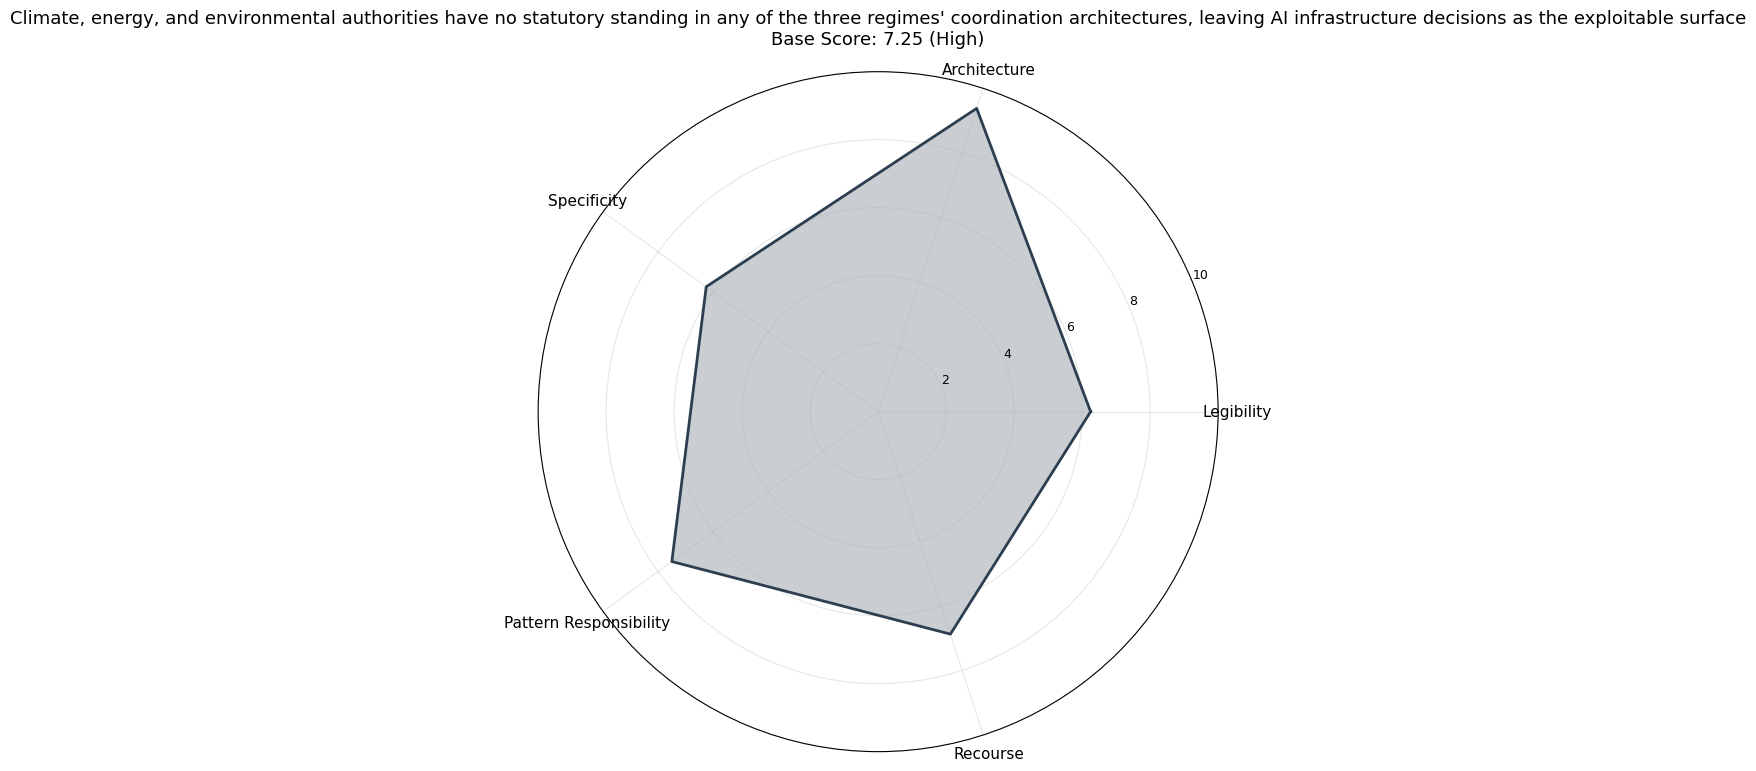

In [31]:
radar_chart(v4)

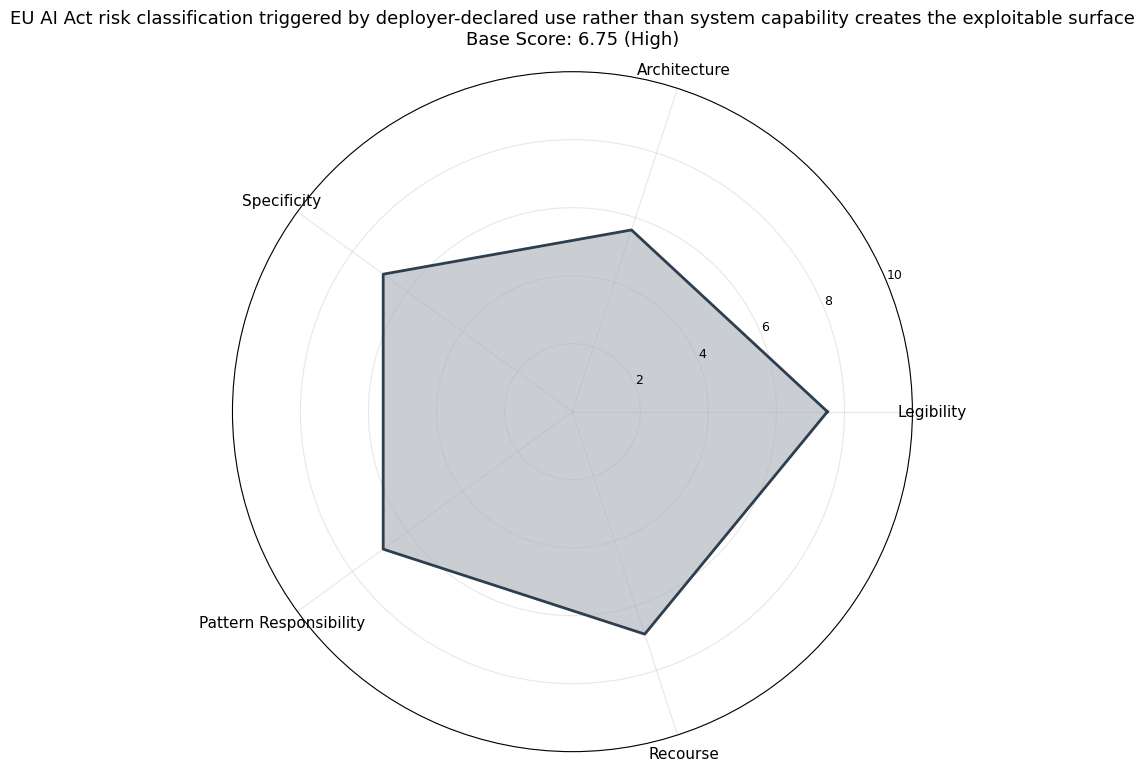

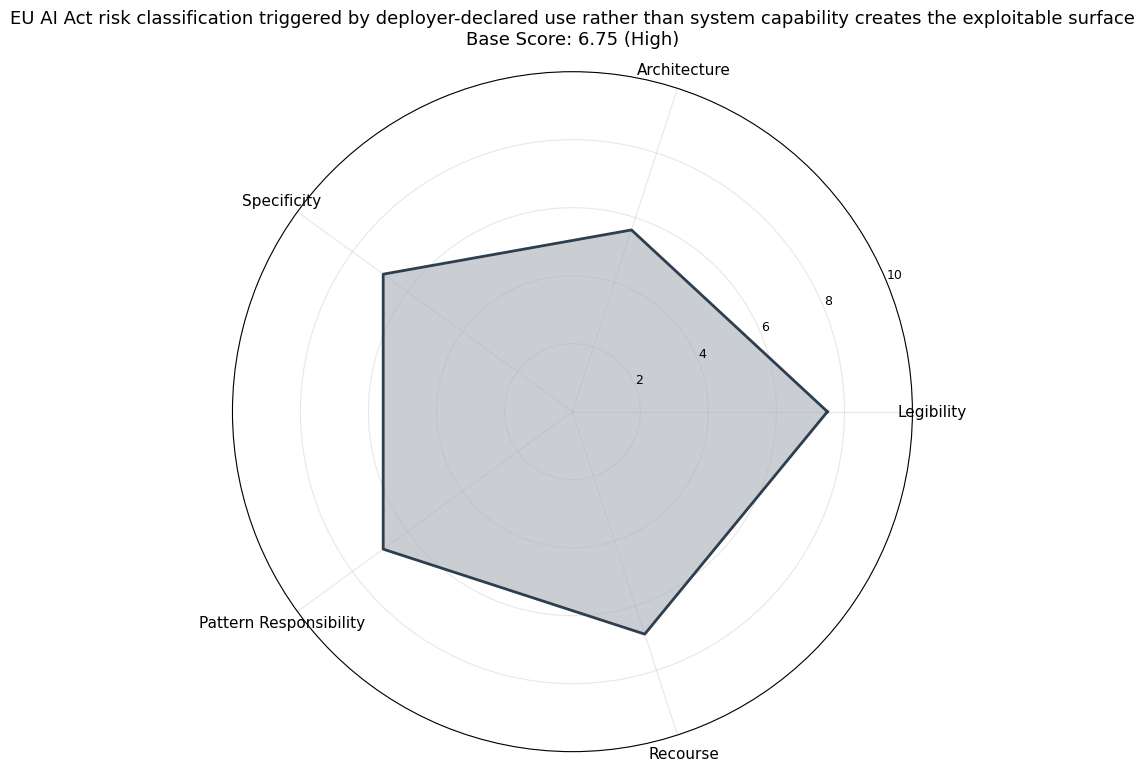

In [32]:
radar_chart(v5)

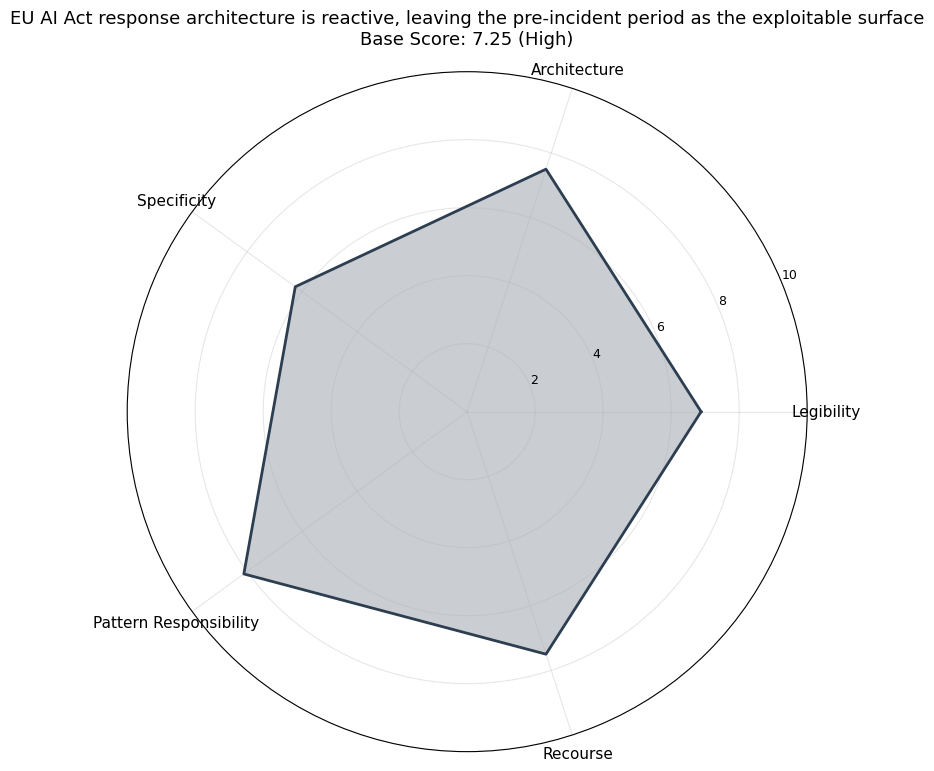

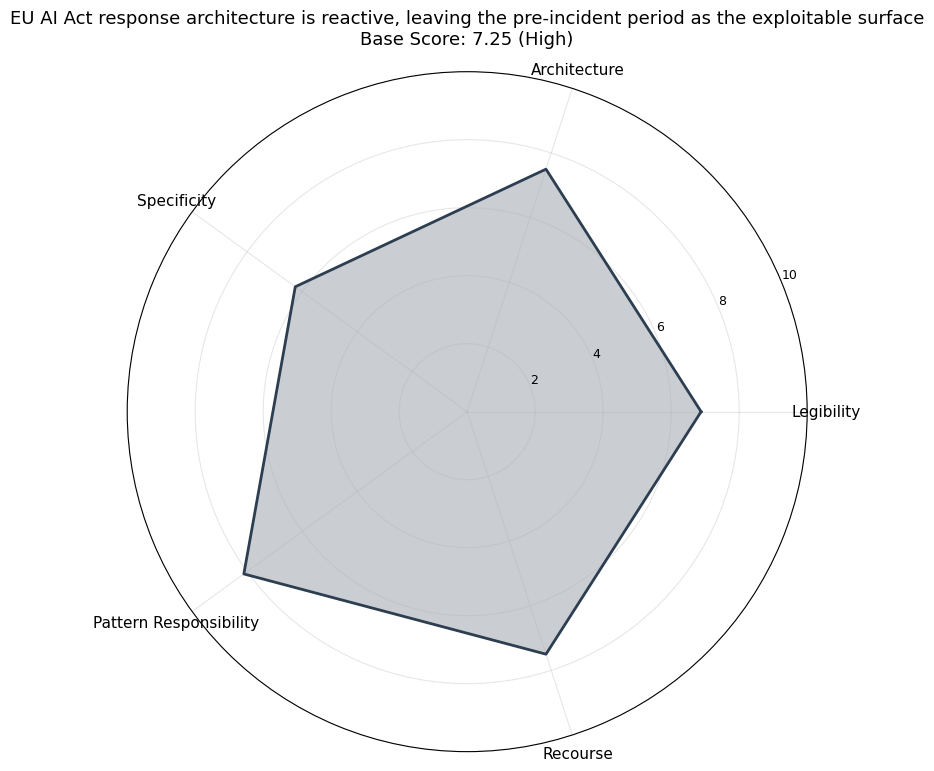

In [33]:
radar_chart(v6)

---

## Generate the report

Saves a markdown report and CSV export of the full analysis to the `outputs/` folder.

In [34]:
generate_report(analysis, output_dir='../outputs')

Report saved: ../outputs/GDPR_+_EU_AI_Act_+_PIPEDA_(Combined_Rights-and-Data_Governance_Analysis)_VMPD_report.md
Data saved: ../outputs/GDPR_+_EU_AI_Act_+_PIPEDA_(Combined_Rights-and-Data_Governance_Analysis)_VMPD_data.csv


'../outputs/GDPR_+_EU_AI_Act_+_PIPEDA_(Combined_Rights-and-Data_Governance_Analysis)_VMPD_report.md'

---

## Notes on this worked example

This is the first VMPD worked example, demonstrating the methodology applied to one policy domain: rights-and-data governance, across three regimes (GDPR, the EU AI Act, PIPEDA). VMPD is a methodology for policy design generally, not specifically for AI policy. AI is the substrate where the structural failures VMPD diagnoses become acute and visible, but the methodology applies to any governance regime where downstream enforcement depends on upstream conditions, where actors will be held accountable for outcomes they have no role in shaping, where pattern recognition is assumed without being assigned, or where recourse mechanisms are formalised without being accessible.

Subsequent worked examples will demonstrate VMPD applied to other policy substrates beyond rights-and-data governance.

The six vulnerabilities surfaced in this analysis are not exhaustive. VMPD applied comprehensively to GDPR, the EU AI Act, and PIPEDA would surface additional findings. The scores represent the analyst's judgment as of v1.0 and are open to contestation. Disagreement on specific sub-metric scores is analytically productive — it surfaces which judgments are contested and why.

---

*VMPD v1.0, Bhavyatta Bhardwaj, 2026*

*Citation: Bhardwaj, B. (2026). Vulnerability Management for Policy Design (VMPD) to Diagnose Structural Failures in Governance Regimes, v1.0. Zenodo. [10.5281/zenodo.19958977]*

*Companion paper: Bhardwaj, B. (2026). Security-by-design: A Case for Digital Rights Enforcement Through Data Pipeline Attestations.*